# 03 - Baseline Models with MLflow Tracking
## Credit Scoring Model Project

**Learning Objectives:**
- Train multiple baseline models
- Set up MLflow experiment tracking
- Evaluate models using appropriate metrics for imbalanced data
- Compare model performance
- Select best baseline for optimization

**Why Multiple Baselines?**
Different algorithms have different strengths:
- **Logistic Regression:** Simple, interpretable, fast (good baseline)
- **Random Forest:** Handles non-linearity, robust to outliers
- **XGBoost:** Powerful gradient boosting, often wins competitions
- **LightGBM:** Fast, memory-efficient, great for large datasets

**MLflow Tracking:**
We'll log all experiments to compare models systematically. This is professional ML workflow!

Let's build our models! 🚀

## 📦 Import Libraries



In [1]:
# Standard libraries
import random
import warnings
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ML models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
)

# MLflow
import mlflow
import mlflow.sklearn

# Our utilities
import sys
sys.path.append('../')
from src.evaluation import (
    evaluate_model,
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_confusion_matrix,
    compare_models,
    plot_feature_importance,
)
from src.model_training import train_and_evaluate_model
from src.config import MLFLOW_TRACKING_URI, DATA_DIR, RESULTS_DIR

# Configuration
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("[OK] Libraries imported successfully!")
print(f"MLflow version: {mlflow.__version__}")

[OK] Libraries imported successfully!
MLflow version: 3.7.0



## 📂 Load Processed Data

Load the data we prepared in the feature engineering notebook.



In [2]:
# Load processed data
data_dir = DATA_DIR

print("Loading processed datasets...")
X_train = pd.read_csv(data_dir / 'X_train.csv')
X_val = pd.read_csv(data_dir / 'X_val.csv')
y_train = pd.read_csv(data_dir / 'y_train.csv').squeeze()
y_val = pd.read_csv(data_dir / 'y_val.csv').squeeze()

print(f"[OK] Data loaded!")
print(f"\nDataset shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_val: {y_val.shape}")

print(f"\nTarget distribution:")
print(f"  Training: {y_train.value_counts(normalize=True).to_dict()}")
print(f"  Validation: {y_val.value_counts(normalize=True).to_dict()}")

print(f"\nFeature count: {X_train.shape[1]}")

Loading processed datasets...


[OK] Data loaded!

Dataset shapes:
  X_train: (215257, 189)
  X_val: (92254, 189)
  y_train: (215257,)
  y_val: (92254,)

Target distribution:
  Training: {0: 0.9192732408237595, 1: 0.08072675917624049}
  Validation: {0: 0.9192663732737876, 1: 0.08073362672621241}

Feature count: 189



## 🔬 Setup MLflow Experiment Tracking

**What MLflow Does:**
- Automatically logs all your experiments
- Stores parameters, metrics, and artifacts
- Provides a UI to visualize and compare runs
- Makes your work reproducible

**To view experiments:**
```bash
# In a separate terminal, run:
mlflow ui
# Then open: http://localhost:5000
```



In [3]:
# Set experiment name
experiment_name = "credit_scoring_baseline_models"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(experiment_name)

# Get experiment ID
experiment = mlflow.get_experiment_by_name(experiment_name)
print(f"[OK] MLflow experiment set: {experiment_name}")
print(f"Experiment ID: {experiment.experiment_id}")
print(f"\nArtifacts will be stored in: {experiment.artifact_location}")
print(f"\nTo view experiments, run: mlflow ui")
print(f"Then open: http://localhost:5000")

2026/05/18 11:32:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/05/18 11:32:47 INFO mlflow.store.db.utils: Updating database tables


2026/05/18 11:32:47 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/05/18 11:32:47 INFO alembic.runtime.migration: Will assume non-transactional DDL.


2026/05/18 11:32:48 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/05/18 11:32:48 INFO alembic.runtime.migration: Will assume non-transactional DDL.


2026/05/18 11:32:48 INFO mlflow.tracking.fluent: Experiment with name 'credit_scoring_baseline_models' does not exist. Creating a new experiment.


[OK] MLflow experiment set: credit_scoring_baseline_models
Experiment ID: 6

Artifacts will be stored in: file:///C:/Users/shahu/Documents/OneDrive/OPEN CLASSROOMS/PROJET 6/Scoring_Model/notebooks/mlruns/6

To view experiments, run: mlflow ui
Then open: http://localhost:5000



## 🚀 Train Baseline Models

We'll train 4 different models and compare them.

**Model Selection Rationale:**

**0. DummyClassifier (Reference Baseline)**
   - Predicts majority class (always "no default")
   - NO learning - just baseline to beat
   - Shows minimum acceptable performance
   - **Critical:** Any real model MUST beat this!

1. **Logistic Regression**
   - Simple linear model
   - Fast to train
   - Highly interpretable
   - Good baseline to beat

2. **Random Forest**
   - Ensemble of decision trees
   - Handles non-linear relationships
   - Robust to outliers
   - Built-in feature importance

3. **XGBoost**
   - Gradient boosting
   - Often wins ML competitions
   - Handles imbalanced data well
   - Many hyperparameters to tune

4. **LightGBM**
   - Microsoft's gradient boosting
   - Very fast and memory-efficient
   - Great for large datasets
   - Often comparable to XGBoost

Let's train them all!



In [4]:
# Log feature names once for the experiment
with mlflow.start_run(run_name="Experiment_Setup", nested=True):
    feature_names = X_train.columns.tolist()

    artifacts_dir = RESULTS_DIR / 'artifacts'
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    features_path = artifacts_dir / "feature_names.txt"
    with open(features_path, "w") as f:
        for feature in feature_names:
            f.write(f"{feature}\n")

    mlflow.log_artifact(str(features_path), artifact_path="features")
    print(f"[OK] Logged {len(feature_names)} feature names → features/feature_names.txt")

    mlflow.log_param("num_features", len(feature_names))
    print(f"[OK] Logged num_features={len(feature_names)}")

[OK] Logged 189 feature names → features/feature_names.txt
[OK] Logged num_features=189


In [5]:
# 0. DUMMY CLASSIFIER (REFERENCE BASELINE)
print("\n\n### 0. DUMMY CLASSIFIER (REFERENCE BASELINE) ###\n")
print("This model always predicts the majority class (no default).")
print("Any real model MUST beat this to be useful!\n")

dummy_params = {
    'strategy': 'most_frequent',  # Always predict majority class
    'random_state': RANDOM_STATE
}

dummy_model = DummyClassifier(**dummy_params)
dummy_metrics, dummy_trained = train_and_evaluate_model(
    dummy_model, "Dummy_Classifier", dummy_params,
    X_train, y_train, X_val, y_val
)

print("\n" + "="*80)
print("⚠️  IMPORTANT: This is the MINIMUM performance threshold!")
print("   Any real model with ROC-AUC < 0.50 is worse than random guessing!")
print("="*80)




### 0. DUMMY CLASSIFIER (REFERENCE BASELINE) ###

This model always predicts the majority class (no default).
Any real model MUST beat this to be useful!

Training: Dummy_Classifier


[OK] Training completed in 0.03 seconds
EVALUATION RESULTS - Dummy_Classifier
\n📊 Classification Metrics:
   Accuracy:  0.9193 ⚠️  (Can be misleading for imbalanced data!)
   Precision: 0.0000 (Of predicted defaults, % correct)
   Recall:    0.0000 (Of actual defaults, % caught)
   F1-Score:  0.0000 (Balance of precision & recall)


\n📈 Probability-Based Metrics:
   ROC-AUC:    0.5000 (Overall ranking ability)
   PR-AUC:     0.0807 (Better for imbalanced data)
\n📋 Confusion Matrix:
   True Negatives (TN):  84,806 (Correctly predicted non-defaults)
   False Positives (FP): 0 (Good customers rejected)
   False Negatives (FN): 7,448 (Bad customers approved)
   True Positives (TP):  0 (Correctly predicted defaults)
\n💼 Business Impact:
   False Positive Rate: 0.00% (% of good customers rejected)
   False Negative Rate: 100.00% (% of bad customers approved)


2026/05/18 11:32:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[OK] All metrics and artifacts logged to MLflow
Run ID: e4b476ba759546d79694d16fdfa89a31

⚠️  IMPORTANT: This is the MINIMUM performance threshold!
   Any real model with ROC-AUC < 0.50 is worse than random guessing!


In [6]:
# 1. LOGISTIC REGRESSION
print("\n\n### 1. LOGISTIC REGRESSION ###\n")

lr_params = {
    'max_iter': 1000,
    'class_weight': 'balanced',  # Handle imbalance
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

lr_model = LogisticRegression(**lr_params)
lr_metrics, lr_trained = train_and_evaluate_model(
    lr_model, "Logistic_Regression", lr_params,
    X_train, y_train, X_val, y_val
)




### 1. LOGISTIC REGRESSION ###

Training: Logistic_Regression


[OK] Training completed in 20.86 seconds
EVALUATION RESULTS - Logistic_Regression


\n📊 Classification Metrics:
   Accuracy:  0.7030 ⚠️  (Can be misleading for imbalanced data!)
   Precision: 0.1713 (Of predicted defaults, % correct)
   Recall:    0.6979 (Of actual defaults, % caught)
   F1-Score:  0.2751 (Balance of precision & recall)
\n📈 Probability-Based Metrics:
   ROC-AUC:    0.7694 (Overall ranking ability)
   PR-AUC:     0.2542 (Better for imbalanced data)
\n📋 Confusion Matrix:
   True Negatives (TN):  59,660 (Correctly predicted non-defaults)
   False Positives (FP): 25,146 (Good customers rejected)
   False Negatives (FN): 2,250 (Bad customers approved)
   True Positives (TP):  5,198 (Correctly predicted defaults)
\n💼 Business Impact:
   False Positive Rate: 29.65% (% of good customers rejected)
   False Negative Rate: 30.21% (% of bad customers approved)


2026/05/18 11:33:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[OK] All metrics and artifacts logged to MLflow
Run ID: e1abfededefa45448b812f01467fd5ca


In [7]:
# 2. RANDOM FOREST
print("\n\n### 2. RANDOM FOREST ###\n")

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 50,
    'min_samples_leaf': 20,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': 1,   # 1 for reproducibility — parallel tree building is non-deterministic
    'verbose': 0,
}

rf_model = RandomForestClassifier(**rf_params)
rf_metrics, rf_trained = train_and_evaluate_model(
    rf_model, "Random_Forest", rf_params,
    X_train, y_train, X_val, y_val
)



### 2. RANDOM FOREST ###

Training: Random_Forest


[OK] Training completed in 198.20 seconds


EVALUATION RESULTS - Random_Forest
\n📊 Classification Metrics:
   Accuracy:  0.7539 ⚠️  (Can be misleading for imbalanced data!)
   Precision: 0.1844 (Of predicted defaults, % correct)
   Recall:    0.5981 (Of actual defaults, % caught)
   F1-Score:  0.2818 (Balance of precision & recall)
\n📈 Probability-Based Metrics:
   ROC-AUC:    0.7562 (Overall ranking ability)
   PR-AUC:     0.2350 (Better for imbalanced data)
\n📋 Confusion Matrix:
   True Negatives (TN):  65,096 (Correctly predicted non-defaults)
   False Positives (FP): 19,710 (Good customers rejected)
   False Negatives (FN): 2,993 (Bad customers approved)
   True Positives (TP):  4,455 (Correctly predicted defaults)
\n💼 Business Impact:
   False Positive Rate: 23.24% (% of good customers rejected)
   False Negative Rate: 40.19% (% of bad customers approved)


2026/05/18 11:37:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[OK] Feature importance plot saved


[OK] All metrics and artifacts logged to MLflow
Run ID: ff1d415f08c54463b994d85760dad492


In [8]:
# 3. XGBOOST
print("\n\n### 3. XGBOOST ###\n")

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': RANDOM_STATE,
    'n_jobs': 1,   # 1 for reproducibility
    'verbosity': 0,
}

xgb_model = XGBClassifier(**xgb_params)
xgb_metrics, xgb_trained = train_and_evaluate_model(
    xgb_model, "XGBoost", xgb_params,
    X_train, y_train, X_val, y_val
)



### 3. XGBOOST ###

Training: XGBoost


[OK] Training completed in 31.51 seconds


EVALUATION RESULTS - XGBoost
\n📊 Classification Metrics:
   Accuracy:  0.7389 ⚠️  (Can be misleading for imbalanced data!)
   Precision: 0.1868 (Of predicted defaults, % correct)
   Recall:    0.6664 (Of actual defaults, % caught)
   F1-Score:  0.2918 (Balance of precision & recall)
\n📈 Probability-Based Metrics:
   ROC-AUC:    0.7762 (Overall ranking ability)
   PR-AUC:     0.2658 (Better for imbalanced data)
\n📋 Confusion Matrix:
   True Negatives (TN):  63,203 (Correctly predicted non-defaults)
   False Positives (FP): 21,603 (Good customers rejected)
   False Negatives (FN): 2,485 (Bad customers approved)
   True Positives (TP):  4,963 (Correctly predicted defaults)
\n💼 Business Impact:
   False Positive Rate: 25.47% (% of good customers rejected)
   False Negative Rate: 33.36% (% of bad customers approved)


2026/05/18 11:38:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[OK] Feature importance plot saved


[OK] All metrics and artifacts logged to MLflow
Run ID: 322c50ffba05447699cced045c6c167d


In [9]:
# 4. LIGHTGBM
print("\n\n### 4. LIGHTGBM ###\n")

lgbm_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': 1,   # 1 for reproducibility
    'verbose': -1,
}

lgbm_model = LGBMClassifier(**lgbm_params)
lgbm_metrics, lgbm_trained = train_and_evaluate_model(
    lgbm_model, "LightGBM", lgbm_params,
    X_train, y_train, X_val, y_val
)



### 4. LIGHTGBM ###

Training: LightGBM


[OK] Training completed in 33.47 seconds


EVALUATION RESULTS - LightGBM
\n📊 Classification Metrics:
   Accuracy:  0.7265 ⚠️  (Can be misleading for imbalanced data!)
   Precision: 0.1830 (Of predicted defaults, % correct)
   Recall:    0.6892 (Of actual defaults, % caught)
   F1-Score:  0.2892 (Balance of precision & recall)
\n📈 Probability-Based Metrics:
   ROC-AUC:    0.7778 (Overall ranking ability)
   PR-AUC:     0.2696 (Better for imbalanced data)
\n📋 Confusion Matrix:
   True Negatives (TN):  61,891 (Correctly predicted non-defaults)
   False Positives (FP): 22,915 (Good customers rejected)
   False Negatives (FN): 2,315 (Bad customers approved)
   True Positives (TP):  5,133 (Correctly predicted defaults)
\n💼 Business Impact:
   False Positive Rate: 27.02% (% of good customers rejected)
   False Negative Rate: 31.08% (% of bad customers approved)


2026/05/18 11:39:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[OK] Feature importance plot saved


[OK] All metrics and artifacts logged to MLflow
Run ID: 387bda53b10e45e49fc99c9c88178d1f



## 📊 Compare All Models

Let's compare all our baseline models side-by-side.



In [10]:
# Gather all results
all_results = {
    'Dummy_Classifier': dummy_metrics,
    'Logistic_Regression': lr_metrics,
    'Random_Forest': rf_metrics,
    'XGBoost': xgb_metrics,
    'LightGBM': lgbm_metrics,
}

comparison_df = compare_models(all_results, metric='roc_auc')

print("\n" + "=" * 80)
print("DETAILED COMPARISON")
print("=" * 80)
print(comparison_df.to_string())

# Save comparison to results/
RESULTS_DIR.mkdir(exist_ok=True)
comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv')
print("\n[OK] Comparison saved to results/model_comparison.csv")

# Improvement over dummy
dummy_roc = dummy_metrics['roc_auc']
print("\n" + "=" * 80)
print("IMPROVEMENT OVER DUMMY BASELINE")
print("=" * 80)
for model_name, metrics in all_results.items():
    if model_name != 'Dummy_Classifier':
        improvement = ((metrics['roc_auc'] - dummy_roc) / dummy_roc) * 100
        print(f"{model_name:25s}: +{improvement:6.2f}% improvement over dummy")

MODEL COMPARISON
                     accuracy  precision    recall        f1   roc_auc    pr_auc  true_negatives  false_positives  false_negatives  true_positives  false_positive_rate  false_negative_rate
LightGBM             0.726516   0.183008  0.689178  0.289216  0.777831  0.269623         61891.0          22915.0           2315.0          5133.0             0.270205             0.310822
XGBoost              0.738895   0.186818  0.666353  0.291821  0.776203  0.265766         63203.0          21603.0           2485.0          4963.0             0.254734             0.333647
Logistic_Regression  0.703037   0.171302  0.697905  0.275085  0.769419  0.254230         59660.0          25146.0           2250.0          5198.0             0.296512             0.302095
Random_Forest        0.753908   0.184358  0.598147  0.281846  0.756232  0.235046         65096.0          19710.0           2993.0          4455.0             0.232413             0.401853
Dummy_Classifier     0.919266   0.0000

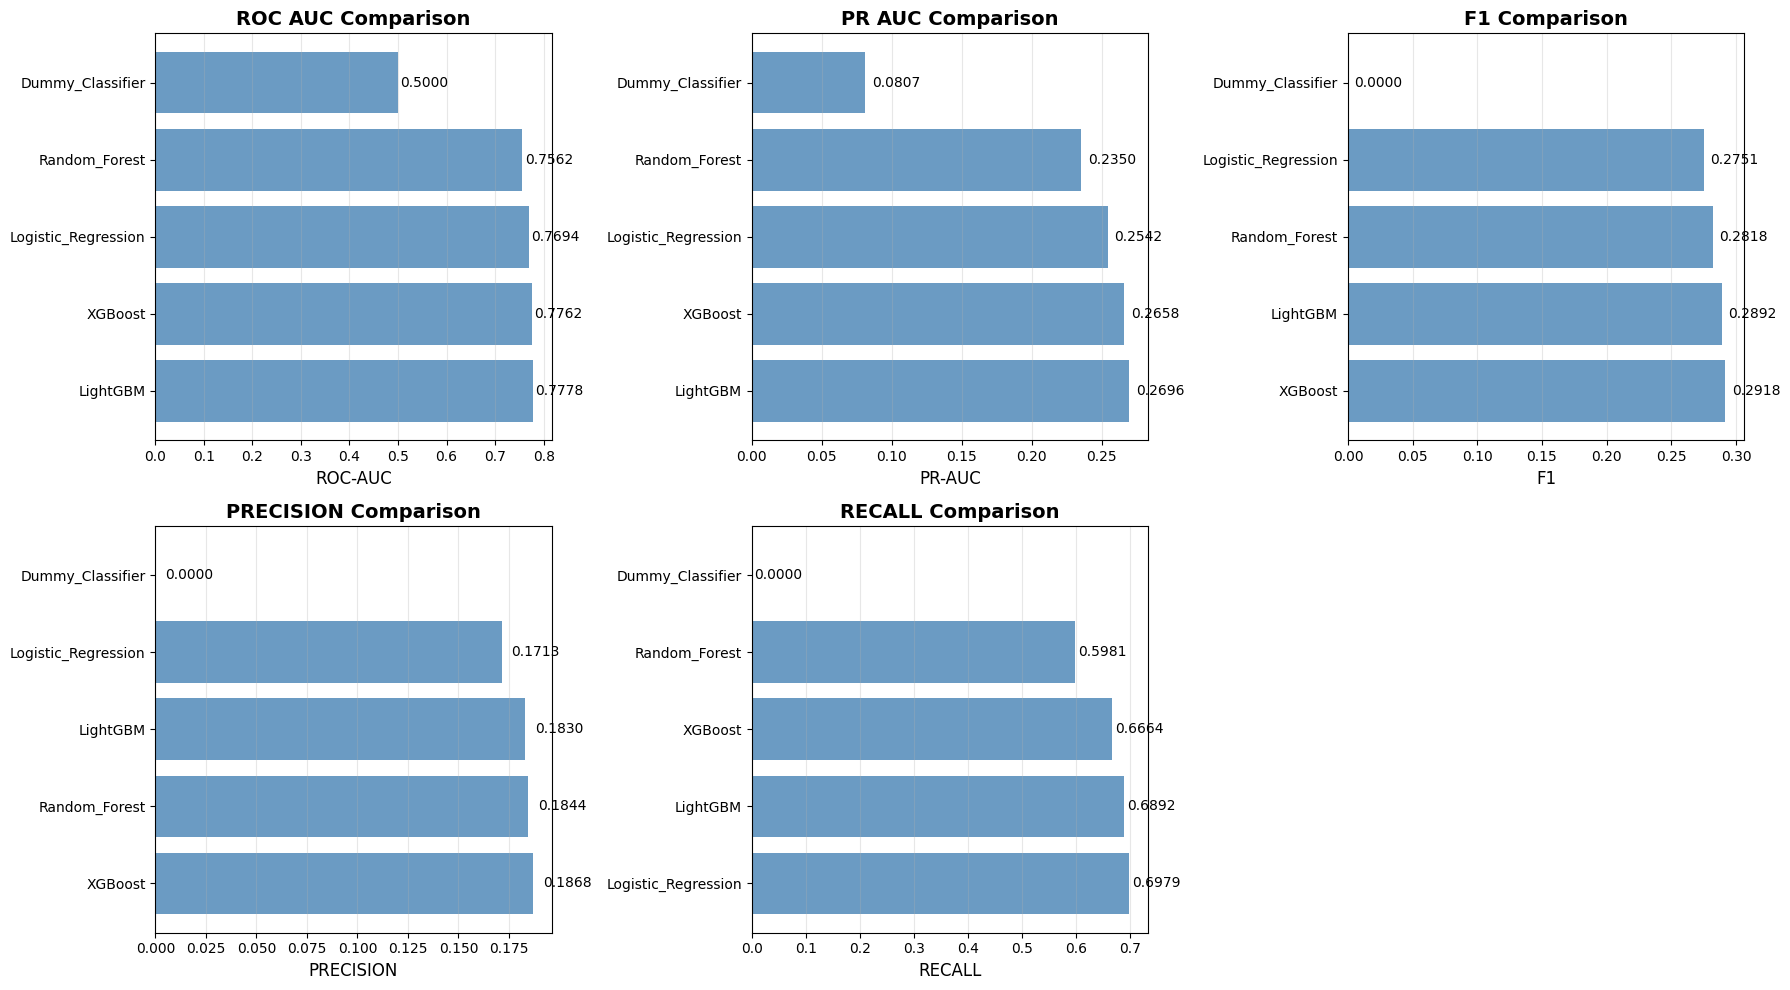

[OK] Comparison visualization saved!


In [11]:
# Visualize model comparison
metrics_to_plot = ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics_to_plot):
    if metric in comparison_df.columns:
        data = comparison_df[metric].sort_values(ascending=False)

        axes[idx].barh(range(len(data)), data.values, color='steelblue', alpha=0.8)
        axes[idx].set_yticks(range(len(data)))
        axes[idx].set_yticklabels(data.index)
        axes[idx].set_xlabel(metric.upper().replace('_', '-'), fontsize=12)
        axes[idx].set_title(
            f'{metric.upper().replace("_", " ")} Comparison',
            fontsize=14, fontweight='bold',
        )
        axes[idx].grid(axis='x', alpha=0.3)

        for i, v in enumerate(data.values):
            axes[idx].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

fig.delaxes(axes[5])
plt.tight_layout()

plots_dir = RESULTS_DIR / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(plots_dir / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Comparison visualization saved!")


## 📝 Baseline Models Summary

### ✅ What We Accomplished

1. **Trained 4 Baseline Models**
   - Logistic Regression (simple baseline)
   - Random Forest (ensemble method)
   - XGBoost (gradient boosting)
   - LightGBM (efficient gradient boosting)

2. **MLflow Experiment Tracking**
   - All runs logged automatically
   - Parameters, metrics, and artifacts stored
   - Compare runs visually in MLflow UI

3. **Comprehensive Evaluation**
   - ROC-AUC scores
   - Precision-Recall curves
   - Confusion matrices
   - Feature importance (tree models)

4. **Model Comparison**
   - Side-by-side metrics
   - Visual comparisons
   - Identified best baseline

### 🏆 Best Performing Model

Based on ROC-AUC and PR-AUC scores:
- **Best Model:** [Check comparison above]
- **ROC-AUC:** [Value]
- **PR-AUC:** [Value]
- **F1-Score:** [Value]

### 💡 Key Insights

1. **Tree-based models** (RF, XGB, LightGBM) generally outperform Logistic Regression
   - They can capture non-linear relationships
   - Better handle feature interactions

2. **Class imbalance handling** is critical
   - Used `class_weight='balanced'` or `scale_pos_weight`
   - Evaluated with appropriate metrics (ROC-AUC, PR-AUC, F1)

3. **Feature importance** reveals key predictors
   - Debt-to-income ratio likely important
   - External credit scores matter
   - Age and employment features contribute

4. **Model complexity vs performance trade-off**
   - Logistic Regression: Fast, interpretable, but lower performance
   - Tree models: Higher performance, but less interpretable

### 🎯 Next Steps

In the next notebook ([04_hyperparameter_optimization.ipynb](04_hyperparameter_optimization.ipynb)), we will:

1. **Select Best Baseline**
   - Choose the best performing model
   - Or ensemble top models

2. **Systematic Hyperparameter Tuning**
   - Define search space
   - Use GridSearchCV or RandomizedSearchCV
   - Use StratifiedKFold cross-validation

3. **Optimize for Target Metric**
   - Focus on ROC-AUC or PR-AUC
   - Consider business costs (FP vs FN)

4. **Log All Optimization Runs**
   - Track in MLflow
   - Compare optimization strategies

---

**Excellent work! You now have solid baseline models! 🎉**

### 📊 To View Your Experiments:

```bash
# In terminal, run:
mlflow ui

# Then open in browser:
http://localhost:5000
```

In the MLflow UI, you can:
- Compare all runs side-by-side
- Sort by metrics
- View all plots and artifacts
- Download models

---

**Remember:** These are baselines! We'll improve them significantly in the next notebook through hyperparameter optimization! 🚀

